SECTION 1: IMPORTS AND SETUP

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


In [5]:
stock_list = [
"AAPL","MSFT","GOOGL","AMZN","TSLA","META","NVDA","JPM","V","JNJ",
"WMT","PG","MA","UNH","HD","BAC","DIS","XOM","PFE","KO",
"CSCO","PEP","T","CVX","MRK","ABT","ADBE","CMCSA","CRM","ACN",
"NFLX","INTC","ORCL","MCD","COST","NKE","WFC","AMD","TXN","LIN",
"DHR","QCOM","UPS","PM","NEE","RTX","IBM","HON","LOW","UNP",
"SBUX","INTU","AMGN","GS","SPGI","BLK","CAT","BA","PLD","MDT",
"AXP","GILD","DE","BKNG","ADP","ISRG","TJX","SYK","LRCX","AMAT",
"ZTS","NOW","TGT","MO","CI","SCHW","CB","MMC","DUK","SO",
"BDX","C","EL","GE","FIS","CSX","AON","HUM","CL","APD",
"FISV","WM","NSC","VRTX","ITW","PNC","ICE","EW","PSA","MCO"
]

print("Total stocks available:", len(stock_list))

Total stocks available: 100


In [6]:
stock = "AAPL"
df = yf.download(stock, start="2015-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


SECTION 2: DATA COLLECTION (yfinance)

In [7]:
stock_symbol = "AAPL"

data = yf.download(stock_symbol, start="2018-01-01", end="2024-01-01")

data = data[['Close']]
data.dropna(inplace=True)

data.head()
stock_symbol = "AAPL"

data = yf.download(stock_symbol, start="2018-01-01", end="2024-01-01")

data = data[['Close']]
data.dropna(inplace=True)

data.head()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2018-01-02,40.304169
2018-01-03,40.297161
2018-01-04,40.484333
2018-01-05,40.945267
2018-01-08,40.793186


SECTION 3: LSTM PREDICTION (Base System)
DATA PREPROCESSING

In [8]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

X, y = [], []

for i in range(90, len(scaled_data)):
    X.append(scaled_data[i-90:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)


TRAIN-TEST SPLIT 

In [9]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


BUILD AND TRAIN LSTM

In [10]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0339
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0015
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0010
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 9.8201e-04
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0010    
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0010
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 9.0071e-04
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 8.6324e-04
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 8.7731e-04
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 7.6625e-04


In [11]:
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 7.8004e-04 - val_loss: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 8.1834e-04 - val_loss: 0.0016
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 6.9475e-04 - val_loss: 8.9748e-04
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 7.4585e-04 - val_loss: 8.7189e-04
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 7.2039e-04 - val_loss: 8.2962e-04
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 6.7131e-04 - val_loss: 0.0013
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 6.3262e-04 - val_loss: 0.0016
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 6.0270e-04 - val_loss: 7.6119e-04
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 6.5649e-04 - val_loss: 7.7887e-04
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 5.6963e-04 - val_loss: 0.0017
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 5.9536e-04 - val_loss: 8.6923

In [12]:
model.save("lstm_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [13]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mean_squared_error'
)


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 5.2222e-04 - val_loss: 7.7632e-04
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 4.4272e-04 - val_loss: 4.6891e-04
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 4.3053e-04 - val_loss: 5.3457e-04
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 4.4016e-04 - val_loss: 0.0011
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 3.7829e-04 - val_loss: 4.1513e-04
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 3.6990e-04 - val_loss: 4.0154e-04
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 3.8293e-04 - val_loss: 6.8903e-04
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 3.5201e-04 - val_loss: 8.0544e-04
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 3.8159e-04 - val_loss: 4.3049e-04
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 4.2100e-04 - val_loss: 5.1676e-04
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 3.2058e-04 - 

Plotting loss curve to check if modedl is actually bad

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 3.9912e-04 - val_loss: 4.0735e-04
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 4.9457e-04 - val_loss: 5.8224e-04
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 3.7530e-04 - val_loss: 7.3603e-04
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 3.4450e-04 - val_loss: 3.6767e-04
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 3.3351e-04 - val_loss: 3.5991e-04
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 3.3790e-04 - val_loss: 3.5162e-04
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 3.2068e-04 - val_loss: 5.0887e-04
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 3.3163e-04 - val_loss: 3.3558e-04
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 3.0733e-04 - val_loss: 9.3577e-04
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 3.2390e-04 - val_loss: 3.5253e-04
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 3.1840e-0

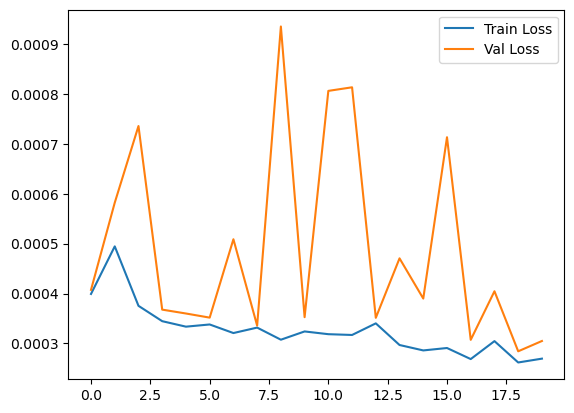

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


PREDICTION AND GRAPH

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


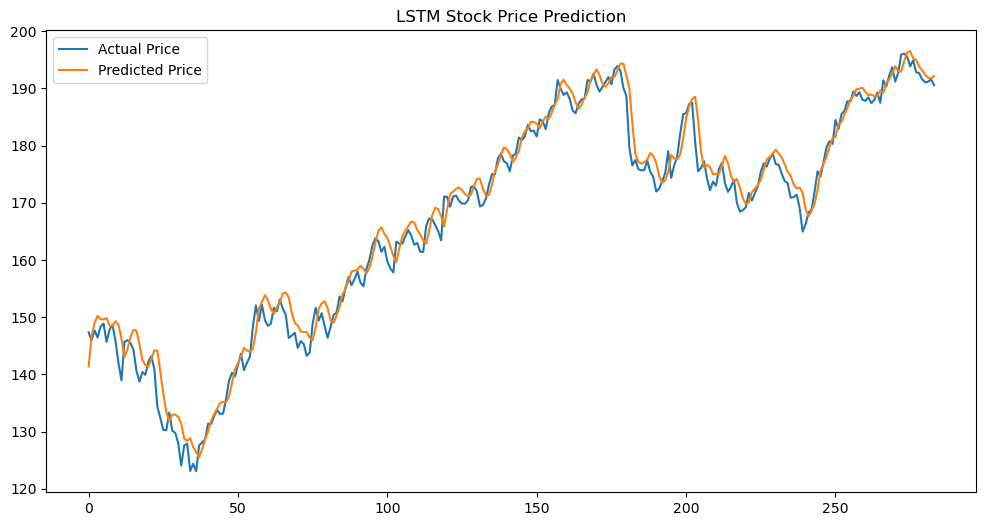

In [16]:
predicted_price = model.predict(X_test)

predicted_price = scaler.inverse_transform(predicted_price)
actual_price = scaler.inverse_transform(y_test.reshape(-1,1))

plt.figure(figsize=(12,6))
plt.plot(actual_price, label="Actual Price")
plt.plot(predicted_price, label="Predicted Price")
plt.legend()
plt.title("LSTM Stock Price Prediction")
plt.show()


SECTION 4: PORTFOLIO ANALYSIS

In [17]:
portfolio_stocks = ["AAPL", "MSFT", "GOOGL", "TSLA"]
returns = {}

for stock in portfolio_stocks:
    df = yf.download(stock, period="1y")
    returns[stock] = float(df['Close'].pct_change().mean())

returns


[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_12972\2385742512.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  returns[stock] = float(df['Close'].pct_change().mean())
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_12972\2385742512.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  returns[stock] = float(df['Close'].pct_change().mean())
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_12972\2385742512.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  returns[stock] = float(df['Close'].pct_change

{'AAPL': 0.0004981586279942325,
 'MSFT': 9.612510074753142e-05,
 'GOOGL': 0.0021927113502493273,
 'TSLA': 0.0014071825479920242}

SECTION 5: RISK ANALYSIS

In [18]:
risk_score = {}

for stock in portfolio_stocks:
    df = yf.download(stock, period="1y")
    risk_score[stock] = float(df['Close'].pct_change().std())


[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_12972\2177750247.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  risk_score[stock] = float(df['Close'].pct_change().std())
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_12972\2177750247.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  risk_score[stock] = float(df['Close'].pct_change().std())
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_12972\2177750247.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  risk_score[stock] = float(df['Close'].pct

SECTION 6: CONFIDENCE SCORE

In [19]:
confidence_score = {}

for stock in portfolio_stocks:
    confidence_score[stock] = returns[stock] / risk_score[stock]

confidence_score


{'AAPL': 0.024633077944189036,
 'MSFT': 0.005780299230711307,
 'GOOGL': 0.11238202094488452,
 'TSLA': 0.03626618339663152}

SECTION 7: SENTIMENT ANALYSIS

In [20]:
sentiment_score = {
    "AAPL": 0.3,
    "MSFT": 0.25,
    "GOOGL": 0.1,
    "TSLA": -0.2
}


SECTION 8: FINAL DECISION ENGINE

In [21]:
def investment_decision(stock):
    ret = float(returns[stock])
    risk = float(risk_score[stock])
    sentiment = float(sentiment_score[stock])

    if ret > 0 and sentiment > 0.2 and risk < 0.03:
        return "BUY"
    elif ret < 0 or sentiment < -0.2:
        return "SELL"
    else:
        return "HOLD"


In [22]:
final_decisions = {}

for stock in portfolio_stocks:
    final_decisions[stock] = investment_decision(stock)

final_decisions


{'AAPL': 'BUY', 'MSFT': 'BUY', 'GOOGL': 'HOLD', 'TSLA': 'HOLD'}

SECTION 9: RESULTS AND OUTPUT

In [23]:
result_df = pd.DataFrame({
    "Return": returns,
    "Risk": risk_score,
    "Confidence": confidence_score,
    "Sentiment": sentiment_score,
    "Decision": final_decisions
})

result_df


,Return,Risk,Confidence,Sentiment,Decision
AAPL,0.000498,0.020223,0.024633,0.30,BUY
MSFT,0.000096,0.016630,0.005780,0.25,BUY
GOOGL,0.002193,0.019511,0.112382,0.10,HOLD
TSLA,0.001407,0.038802,0.036266,-0.20,HOLD


GRAPH: RISK vs RETURN

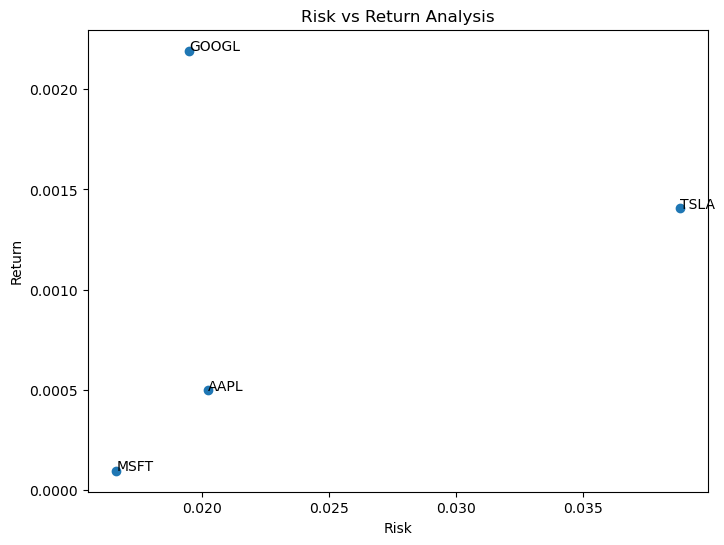

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(result_df["Risk"], result_df["Return"])

for stock in result_df.index:
    plt.text(result_df["Risk"][stock], result_df["Return"][stock], stock)

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Risk vs Return Analysis")
plt.show()


DYNAMIC PREDICTION FUNCTION

In [25]:
def predict_stock(stock_symbol):
    
    print(f"Fetching data for {stock_symbol}...")
    
    df = yf.download(stock_symbol, period="5y", progress=False)
    
    if df.empty:
        print("Invalid stock symbol.")
        return
    
    data = df[['Close']]
    
    scaler = MinMaxScaler(feature_range=(0,1))
    scaled_data = scaler.fit_transform(data)
    
    X = []
    for i in range(60, len(scaled_data)):
        X.append(scaled_data[i-60:i])
    
    X = np.array(X)
    
    X_input = X[-1].reshape(1,60,1)
    
    predicted_scaled = model.predict(X_input)
    predicted_price = scaler.inverse_transform(predicted_scaled)[0][0]
    
    current_price = data.values[-1][0]
    
    prices = data.values.flatten()
    returns = np.diff(prices) / prices[:-1]
    
    risk = np.std(returns)
    
    confidence = (predicted_price - current_price) / (current_price * risk + 1e-6)
    
    if confidence > 1:
        decision = "BUY"
    elif confidence < -1:
        decision = "SELL"
    else:
        decision = "HOLD"
    
    print("Current Price:", current_price)
    print("Predicted Next Price:", predicted_price)
    print("Risk:", risk)
    print("Confidence:", confidence)
    print("Decision:", decision)
    
    return {
        "stock": stock_symbol,
        "current_price": current_price,
        "predicted_price": predicted_price,
        "risk": risk,
        "confidence": confidence,
        "decision": decision
    }

TEST WITH ANY STOCK

In [26]:
df_test = yf.download("TSLA", start="2015-01-01", end="2024-01-01")
print(df_test.head())
print("Is dataframe empty?", df_test.empty)

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                            
2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500
Is dataframe empty? False


In [27]:
predict_stock("TSLA")

Fetching data for TSLA...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
Current Price: 420.29998779296875
Predicted Next Price: 428.40057
Risk: 0.03801435029404062
Confidence: 0.5070017481831127
Decision: HOLD


{'stock': 'TSLA',
 'current_price': np.float64(420.29998779296875),
 'predicted_price': np.float32(428.40057),
 'risk': np.float64(0.03801435029404062),
 'confidence': np.float64(0.5070017481831127),
 'decision': 'HOLD'}